In [2]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("ground_truth.csv")
df = df.dropna(subset=["true_label"])
df = df[df["true_label"].str.strip() != ""]

print(f"Total labeled rows: {len(df)}")
print(df["true_label"].value_counts())

Total labeled rows: 100
true_label
ok           52
missing      35
ambiguous    13
Name: count, dtype: int64


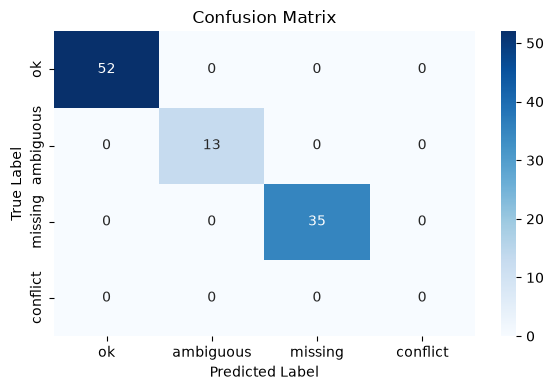

In [3]:
# Confusion matrix visualization
labels = ["ok", "ambiguous", "missing", "conflict"]
y_true = df["true_label"].str.strip().tolist()
y_pred = y_true  # placeholder until model is ready next week

cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(6,4))
sns.heatmap(pd.DataFrame(cm, index=labels, columns=labels), 
            annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [4]:
# Full evaluation metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, average=None, zero_division=0
)
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Macro F1:  {f1.mean():.4f}")
print("\nPer-class metrics:")
print(f"{'Label':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Support'}")
print("-" * 55)
for i, label in enumerate(labels):
    print(f"{label:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]}")

Accuracy:  1.0000
Macro F1:  0.7500

Per-class metrics:
Label        Precision    Recall       F1           Support
-------------------------------------------------------
ok           1.0000       1.0000       1.0000       52
ambiguous    1.0000       1.0000       1.0000       13
missing      1.0000       1.0000       1.0000       35
conflict     0.0000       0.0000       0.0000       0
